<a href="https://colab.research.google.com/github/rishiraj4/Car-Parts-Detection-YOLO11/blob/main/CV_Course_Project_Rishi_Raj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CV Course Project**

In [ ]:
# 1. Install YOLO v11 (via ultralytics)
!pip install ultralytics -q

# 2. Clone the Course Project Dataset
!git clone https://github.com/dsmlr/Car-Parts-Segmentation.git

# 3. Import necessary libraries
import os
import json
import shutil
import cv2
import numpy as np
import yaml
from ultralytics import YOLO
import matplotlib.pyplot as plt
from glob import glob

print("Setup Complete. GPU is ready.")

fatal: destination path 'Car-Parts-Segmentation' already exists and is not an empty directory.
Setup Complete. GPU is ready.


In [ ]:
# Clean up previous failed attempts
if os.path.exists("yolo_dataset"):
    shutil.rmtree("yolo_dataset")

# Define the exact paths
# We search for the folders to avoid path errors
repo_root = "Car-Parts-Segmentation"
train_search = glob(f"{repo_root}/**/trainingset", recursive=True)
test_search = glob(f"{repo_root}/**/testset", recursive=True)

# Select the folders that actually contain images
source_train_dir = [d for d in train_search if "images" not in d][0] # usually the root 'train'
source_test_dir = [d for d in test_search if "images" not in d][0]  # usually the root 'test'

print(f"Found source training data at: {source_train_dir}")
print(f"Found source testing data at: {source_test_dir}")

# Create YOLO Directory Structure
base_dir = "yolo_dataset"
os.makedirs(f"{base_dir}/images/train", exist_ok=True)
os.makedirs(f"{base_dir}/images/val", exist_ok=True)
os.makedirs(f"{base_dir}/labels/train", exist_ok=True)
os.makedirs(f"{base_dir}/labels/val", exist_ok=True)

# Helper Function to Convert and Copy
def process_dataset(json_path, src_img_dir, dst_img_dir, dst_lbl_dir, class_map):
    with open(json_path, 'r') as f:
        data = json.load(f)

    # Map image_id to annotations
    img_to_anns = {}
    if 'annotations' in data:
        for ann in data['annotations']:
            img_to_anns.setdefault(ann['image_id'], []).append(ann)

    count = 0
    for img_data in data['images']:
        filename = img_data['file_name']

        # SEARCH for the image file in the source directory (ignoring case/exact path issues)
        # Some repos have images inside another subfolder or flat
        possible_files = glob(f"{src_img_dir}/**/{filename}", recursive=True)

        if not possible_files:
            continue

        src_file = possible_files[0]
        dst_file = os.path.join(dst_img_dir, filename)

        shutil.copy(src_file, dst_file)
        count += 1

        # Create Label File
        img_id = img_data['id']
        img_w = img_data['width']
        img_h = img_data['height']

        if img_id in img_to_anns:
            txt_filename = os.path.splitext(filename)[0] + ".txt"
            with open(os.path.join(dst_lbl_dir, txt_filename), 'w') as f_out:
                for ann in img_to_anns[img_id]:
                    cat_id = ann['category_id']
                    if cat_id in class_map:
                        # Convert to YOLO (x_center, y_center, w, h)
                        bbox = ann['bbox'] # [xmin, ymin, w, h]
                        xc = (bbox[0] + bbox[2]/2) / img_w
                        yc = (bbox[1] + bbox[3]/2) / img_h
                        w_norm = bbox[2] / img_w
                        h_norm = bbox[3] / img_h

                        f_out.write(f"{class_map[cat_id]} {xc} {yc} {w_norm} {h_norm}\n")
    return count

# 5. Execute Conversion
# Find the JSON files (they are named annotations.json)
train_json = glob(f"{source_train_dir}/*.json")[0]
test_json = glob(f"{source_test_dir}/*.json")[0]

# Extract Classes
with open(train_json, 'r') as f:
    cats = json.load(f)['categories']
    cats.sort(key=lambda x: x['id'])
    class_map = {c['id']: i for i, c in enumerate(cats)}
    class_names = [c['name'] for c in cats]

print("Processing Training Images...")
train_count = process_dataset(train_json, source_train_dir, f"{base_dir}/images/train", f"{base_dir}/labels/train", class_map)
print(f"--> Successfully moved {train_count} training images.")

print("Processing Validation Images...")
val_count = process_dataset(test_json, source_test_dir, f"{base_dir}/images/val", f"{base_dir}/labels/val", class_map)
print(f"--> Successfully moved {val_count} validation images.")

# 6. Create YAML and Train
yaml_content = f"""
path: {os.path.abspath(base_dir)}
train: images/train
val: images/val
nc: {len(class_names)}
names: {class_names}
"""
with open(f"{base_dir}/data.yaml", "w") as f:
    f.write(yaml_content)

if train_count > 0:
    print("Starting Training...")
    model = YOLO("yolo11n.pt")
    model.train(data=f"{base_dir}/data.yaml", epochs=50, imgsz=640, batch=16, project="car_parts_project", name="yolo11_run")
else:
    print("ERROR: No images were found. Please check the repo structure manually.")

Found source training data at: Car-Parts-Segmentation/trainingset
Found source testing data at: Car-Parts-Segmentation/testset
Processing Training Images...
--> Successfully moved 400 training images.
Processing Validation Images...
--> Successfully moved 100 validation images.
Starting Training...
New https://pypi.org/project/ultralytics/8.3.241 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.240 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, h

**Question 1 and 2**

Ultralytics 8.3.240 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,585,857 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 846.7±502.2 MB/s, size: 35.4 KB)
val: Scanning /content/yolo_dataset/labels/val.cache... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 202.4Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 2.2it/s 3.2s
                   all        100        811      0.584      0.809      0.652       0.51
           back_bumper         18         18       0.82      0.889        0.9      0.772
            back_glass         20         20      0.638        0.8      0.821      0.651
        back_left_door         31         31      0.399      0.837      0.515      0.391
       back_left_light         20         20      0.427        0.8      0.571      0.414
       back_right_door         29         29 

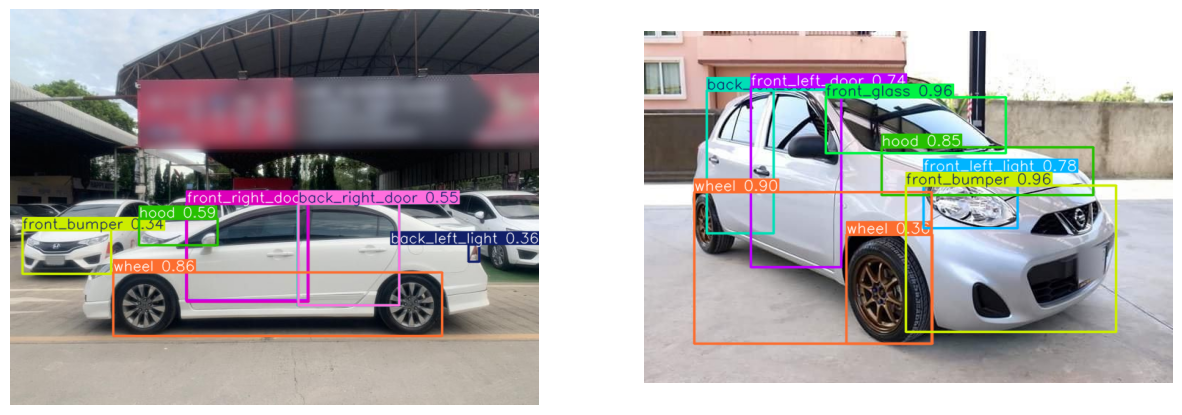

In [ ]:
import random
# Load the model you just trained
# Note: The path might vary slightly, so we use the best.pt directly
model = YOLO("car_parts_project/yolo11_run2/weights/best.pt")

# Q1: Get mAP Metrics
metrics = model.val()
print(f"mAP@50: {metrics.box.map50:.4f}")
print(f"mAP@50-95: {metrics.box.map:.4f}")

# Q2: Visualize Predictions

val_images = glob("yolo_dataset/images/val/*.jpg")
samples = random.sample(val_images, 2)

plt.figure(figsize=(15, 8))
for i, img_path in enumerate(samples):
    results = model.predict(img_path, conf=0.25)
    res_plotted = results[0].plot()
    res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 2, i + 1)
    plt.imshow(res_rgb)
    plt.axis("off")
plt.show()

**Question 3**

I examined the validation results table, specifically the mAP@50-95 column, to identify which category is the most challenging to localize. This metric represents the average precision across various Intersection over Union (IoU) thresholds, ranging from 0.50 to 0.95. A lower score in this column indicates that the model struggles to accurately align the predicted bounding box with the ground truth for that particular class.

**Conclusion:** The class with the lowest mAP@50-95 score of 0.235 is left_mirror, making it the hardest to localize accurately.

**Reasoning:** The difficulty likely arises from the size of the object. Mirrors are significantly smaller than other classes, such as front_bumper (0.821) or hood (0.786). Smaller objects pose a challenge for detection and precise localization in object detection tasks, as they provide fewer pixels for feature extraction, especially after the network layers have downsampled the image.

**Question 4**

**Identification of the Issue:** The left mirror is a small object, and the current model may struggle to distinguish its boundaries from the background or the car body due to the standard input resolution of 640x640.

**Recommended Resolution:** I recommend increasing the input image resolution during training to enhance detection accuracy for the left mirror and other small classes, such as lights.

**Action:** Adjust the training configuration by modifying the `imgsz` parameter from 640 to either 1024 or 1280.

**Justification:** Increasing the resolution ensures that mirrors and other small objects occupy more pixels in the feature maps. This change helps the model learn clearer edge and shape features for more accurate localization, preventing important details from being "washed out" during the downsampling process (pooling or strided convolutions).